In [1]:
from dotenv import load_dotenv
import os 
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import AzureChatOpenAI
from langchain_core.output_parsers import StrOutputParser

load_dotenv('env', override=True)
AZURE_OPENAI_API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
END_POINT=os.getenv('END_POINT')
MODEL_NAME=os.getenv('MODEL_NAME')
print(AZURE_OPENAI_API_KEY[:10])
print(MODEL_NAME)

AZURE_OPENAI_EMB_API_KEY = os.getenv('AZURE_OPENAI_EMB_API_KEY')
EMB_END_POINT=os.getenv('EMB_END_POINT')
EMB_MODEL_NAME=os.getenv('EMB_MODEL_NAME')

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_ENDPOINT'] = os.getenv('LANGCHAIN_ENDPOINT')
os.environ['LANGCHAIN_TRACING_V2'] = 'false' #true, false
os.environ['LANGCHAIN_PROJECT'] = 'RAG'

if os.getenv('LANGCHAIN_TRACING_V2') == "true":
    if len(os.getenv('LANGCHAIN_API_KEY')) > 0:
        print('랭스미스로 추적 중입니다 :', os.getenv('LANGSMITH_API_KEY')[:10])
    else:
        print('랭스미스 키가 확인되지 않았습니다.')

43b13g4OZS
gpt-5-mini


# Multi-Turn RAG

랭체인에서 제공하는 메모리의 종류와 제안하는 방법은 아래 링크에 들어가서 참고

https://python.langchain.com/docs/versions/migrating_memory/

https://python.langchain.com/docs/versions/migrating_memory/long_term_memory_agent/

## 1.1 Langchain을 사용한 Multi-Turn RAG

리트리버는 아래 모든 예시에서 사용할 것이므로 공통되게 한번만 구현합니다.

In [2]:
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_openai import AzureOpenAIEmbeddings
from langchain.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
import glob

pdf_folder_dir = "pdf/*이용약관*.pdf"
docs = []
for path in glob.glob(pdf_folder_dir):
        print(path)
        loader = PyMuPDFLoader(path)   
        docs.extend(loader.load())

splitter = RecursiveCharacterTextSplitter(
    chunk_size=600,
    chunk_overlap=100,
    separators=["\n\n", "\n", "  ", " "]
)
splits = splitter.split_documents(docs)
print(f'{len(splits)} chunks')

from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma

emb = AzureOpenAIEmbeddings(
    model=EMB_MODEL_NAME,                      
    api_key=AZURE_OPENAI_EMB_API_KEY,
    azure_endpoint=EMB_END_POINT,
    api_version="2024-08-01-preview"
)
vectordb = FAISS.from_documents(splits,emb)

#save vector db
vectordb.save_local("faiss_index")

retriever = vectordb.as_retriever(search_type="similarity", k=15)
# retriever = vectordb.as_retriever(search_type="similarity_score_threshold", search_kwargs=dict(k = 15, score_threshold=0.6))
# retriever = vectordb.as_retriever(search_type="mmr", search_kwargs=dict(k=15, fetch_k=30, lambda_mult=0.5)) #fetch_k는 검색 범위 조절, lamda_mult는 검색 결과 중 중요한 것을 선택하는 비율

def format_docs(docs):
    return "\n\n-----\n\n".join(d.page_content + f"\n\n <출처>: {d.metadata['source']} - {d.metadata['page']}" for d in docs)

pdf/기업형_메시지_이용약관.pdf
pdf/KT구내통신서비스_이용약관.pdf
pdf/인터넷서비스_이용약관.pdf
566 chunks


기본적인 히스토리는 chatMessageHistory에서 관리할 수 있습니다. 

업데이트는 ai와 user를 골라서 저장 할 수 있고 로드하거나 초기화 할 수 있습니다.

In [7]:
from langchain_community.chat_message_histories import ChatMessageHistory
history = ChatMessageHistory()
history.add_ai_message("안녕하세요. 무엇을 도와드릴까요?")
history.add_user_message("딱히 네 도움은 필요 없어")

print(history.messages)

history.clear()
print(history.messages)

[AIMessage(content='안녕하세요. 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}), HumanMessage(content='딱히 네 도움은 필요 없어', additional_kwargs={}, response_metadata={})]
[]


In [ ]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

prompt = ChatPromptTemplate.from_messages([
    ("system",
     "너는 문서 기반 QA 어시스턴트다. 아래 규칙을 지켜라.\n"
     "1) 제공된 컨텍스트(표/본문)에서만 근거를 찾아 답한다.\n"
     "2) 모르면 모른다고 말한다. 추측 금지.\n"
     "3) 숫자/조건/예외는 정확히 인용하고, 출처 문장 일부를 함께 제시한다.\n"
     "4) 표 내용이라면 행/열 헤더를 함께 언급해 맥락을 명확히 한다.\n"
     "5) 출처 페이지를 마지막에 제시한다.\n"),
     MessagesPlaceholder("chat_history"),  # chat history
    ("human", "질문: {question}\n\n컨텍스트:\n{context}\n\n한국어로 간결하게 답해.") # RAG
])

from operator import itemgetter
from langchain_core.output_parsers import StrOutputParser

llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,  
    azure_deployment=MODEL_NAME,          
    api_version="2024-12-01-preview",
    model = MODEL_NAME,
    # temperature=0.2,
)
parser = StrOutputParser()

rag_chain = (
    {
        "question": itemgetter("question"),
        "context": itemgetter("question") | retriever | format_docs,
        "chat_history": itemgetter("chat_history"),  # ← 메시지 리스트를 그대로 전달
    }   
    | prompt
    | llm
    | parser
)

위와 같이 chat history 칸을 넣어 체인을 생성한 후 아래 코드 처럼 유저가 직접 history를 관리하고 추가할 수 있습니다.

In [ ]:
input_dict = {
    "question": "giga wifi 요금?",
    "chat_history": ChatMessageHistory().messages # user별 대화 기록을 구분하기 위함. 
}
print(rag_chain.invoke(input_dict))

GiGA WiFi 요금은 다음과 같습니다.

- GiGA WiFi home: 99,000원  
- GiGA WiFi home plus: 49,500원  
- GiGA WiFi Premium: 165,000원  
- GiGA WiFi premium plus: 82,500원  
- GiGA WiFi premium 2.4(6E): 132,000원 (‘24년 5월 31일 이전 가입자는 231,000원)  
- GiGA WiFi premium 4.8: 132,000원 (‘24년 5월 31일 이전 가입자는 297,000원)  
(출처: pdf/인터넷서비스_이용약관.pdf - 89)

또한 인터넷 서비스별로 GiGA WiFi 요금 할인도 제공됩니다. 예를 들어, 인터넷 프리미엄플러스 고객은 GiGA WiFi premium 2.4(6E) 및 4.8 AP에서 월 7,700원 할인받습니다.  
(출처: pdf/인터넷서비스_이용약관.pdf - 136, 141)


하지만 이렇게 하면 우리가 계속적으로 과거 대화 내용을 chatmessagehistory에 누적해야 합니다. 

RunnableWithMessageHistory를 사용해서 자동으로 히스토리를 저장할 수 있습니다.

### 대화 기록 - 1. 메모리내에서 사용

- 짧은 대화에 적절한 방법으로 세션 메모리에서만 사용하다가 프로그램이 종료되면 자동으로 삭제된다.

In [12]:
_store = {} 
def get_session_history(session_id: str) -> ChatMessageHistory:
    if session_id not in _store:
        _store[session_id] = ChatMessageHistory()
    return _store[session_id]

### 대화 기록 - 2. 외부에서 관리

- 장기적인 대화 기록이 필요한 경우에 사용. 영구적으로 유저의 대화 내용이 저장된다.

In [14]:
import os
from langchain_community.chat_message_histories import SQLChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory

DB_DIR = "history_data"
os.makedirs(DB_DIR, exist_ok=True)
CONN_STR = f"sqlite:///{os.path.join(DB_DIR, 'chat_history.sqlite')}"

def get_session_history(session_id: str) -> SQLChatMessageHistory:
    return SQLChatMessageHistory(
        session_id=session_id,
        connection=CONN_STR
    )    

def clear_session_history(session_id: str):
    history = get_session_history(session_id)
    history.clear()
    return "세션 기록이 초기화되었습니다."

In [17]:
get_session_history("user1").get_messages()

[]

Context와 History가 추가된 체인에 hitory를 업데이트 해줄 RunnableWithMessageHistory를 씌워주면 간단한 멀티 턴 RAG가 됩니다.

In [18]:
mt_rag = RunnableWithMessageHistory(
    rag_chain,
    get_session_history=get_session_history,
    history_messages_key="chat_history",  
    input_messages_key="question",        
    output_messages_key="output",         
)

In [19]:
def chat(session_id: str, question: str) -> str:
    config = {"configurable": {"session_id": session_id}}

    return mt_rag.invoke({"question": question}, config=config)

In [20]:
print(chat("user1", "giga wifi 요금제에 대해 알려줘"))

GiGA WiFi 요금제는 여러 종류가 있으며, 대표적인 요금은 다음과 같습니다 (출처: pdf/인터넷서비스_이용약관.pdf - 89):

- GiGA WiFi home: 99,000원
- GiGA WiFi home plus: 49,500원
- GiGA WiFi Premium: 165,000원
- GiGA WiFi premium plus: 82,500원
- GiGA WiFi premium 2.4(6E): 132,000원 (2024년 5월 31일 이전 가입자는 231,000원)
- GiGA WiFi premium 4.8: 132,000원 (2024년 5월 31일 이전 가입자는 297,000원)

또한, 단말 임대료 할인 프로모션이 있습니다(출처: pdf/인터넷서비스_이용약관.pdf - 141):

- 인터넷 베이직, 인터넷 에센스 고객 중 GiGA WiFi Premium 2.4(6E)을 신청하면 인터넷 베이직은 2,200원, 인터넷 에센스는 4,400원 할인
- 인터넷 에센스, 인터넷 프리미엄 고객 중 GiGA WiFi Premium 4.8 신청 시 각각 5,500원, 6,600원 할인

프로모션 신청 기간은 2022년 7월 1일부터 2022년 12월 31일까지입니다.

또한, 인터넷 프리미엄플러스 가입자가 GiGA WiFi Premium 2.4(6E)을 신규 신청하면 3년간 월 16,500원 인터넷 요금 할인 혜택도 있습니다(2022년 10월 1일 ~ 2023년 3월 31일 신청 기간).

이 밖에 해지 시 할인반환금이 부과되고, 선납금을 납부한 경우 잔여 모뎀 임대료는 할인 적용됩니다.

요약: GiGA WiFi는 다양한 요금제가 있으며, 단말 임대료 할인과 인터넷 요금 할인 프로모션이 병행 제공됩니다.

(출처: pdf/인터넷서비스_이용약관.pdf - 89, 141)


In [21]:
print('대화 기록 -------------------------------')
print(get_session_history("user1").get_messages())
clear_session_history("user1")
print('대화 기록 ')
print(get_session_history("user1").get_messages())

대화 기록 -------------------------------
[HumanMessage(content='giga wifi 요금제에 대해 알려줘', additional_kwargs={}, response_metadata={}), AIMessage(content='GiGA WiFi 요금제는 여러 종류가 있으며, 대표적인 요금은 다음과 같습니다 (출처: pdf/인터넷서비스_이용약관.pdf - 89):\n\n- GiGA WiFi home: 99,000원\n- GiGA WiFi home plus: 49,500원\n- GiGA WiFi Premium: 165,000원\n- GiGA WiFi premium plus: 82,500원\n- GiGA WiFi premium 2.4(6E): 132,000원 (2024년 5월 31일 이전 가입자는 231,000원)\n- GiGA WiFi premium 4.8: 132,000원 (2024년 5월 31일 이전 가입자는 297,000원)\n\n또한, 단말 임대료 할인 프로모션이 있습니다(출처: pdf/인터넷서비스_이용약관.pdf - 141):\n\n- 인터넷 베이직, 인터넷 에센스 고객 중 GiGA WiFi Premium 2.4(6E)을 신청하면 인터넷 베이직은 2,200원, 인터넷 에센스는 4,400원 할인\n- 인터넷 에센스, 인터넷 프리미엄 고객 중 GiGA WiFi Premium 4.8 신청 시 각각 5,500원, 6,600원 할인\n\n프로모션 신청 기간은 2022년 7월 1일부터 2022년 12월 31일까지입니다.\n\n또한, 인터넷 프리미엄플러스 가입자가 GiGA WiFi Premium 2.4(6E)을 신규 신청하면 3년간 월 16,500원 인터넷 요금 할인 혜택도 있습니다(2022년 10월 1일 ~ 2023년 3월 31일 신청 기간).\n\n이 밖에 해지 시 할인반환금이 부과되고, 선납금을 납부한 경우 잔여 모뎀 임대료는 할인 적용됩니다.\n\n요약: GiGA WiFi는 다양한 요금제가 있으며, 단말 임대료 할인과 인

In [22]:
print(chat("user1", "서비스를 해지하려고 해. 위약금 조항에 대해 알려줘"))

제공된 컨텍스트에서는 구체적인 "위약금" 조항에 관한 내용이 없습니다. 다만, 제19조(서비스 이용계약의 해제 및 해지)에서는 "이용자가 이용계약을 해지하고자 하는 경우 서비스 해지신청서를 회사에 제출하여야 한다"고 규정하고 있고, 제13조(계약의 해제, 해지)에서는 "해지희망일(단, KT biz kornet은 5일전)까지 신청하여야 하며 해지희망일은 해지접수일부터 익월 말일까지의 일자 중에서 예약이 가능하다"고 안내하고 있습니다. 위약금에 대한 직접적인 언급이나 산정 기준은 명시되어 있지 않으니, 위약금 조항에 관한 내용은 확인되지 않습니다.

<출처> pdf/기업형_메시지_이용약관.pdf - 9, pdf/인터넷서비스_이용약관.pdf - 8


In [23]:
print(chat("user1", "그럼 다른 요금제 중에서는?"))

제공된 컨텍스트에 따르면, 다른 요금제 관련 위약금 조항은 명확히 언급되어 있지 않습니다. 다만, 제22조(요금의 반환) 및 제23조(체납요금의 징수) 등에서 요금과 관련된 일반 사항을 다루고 있고, 별표1(인터넷 요금표 등)과 할인·감면 제도를 통해 요금 구조 및 할인율, 감면율이 안내되어 있습니다(예: KT biz kornet 요금의 요금선납 할인, 요금감면 최대 40%). 위약금 산정이나 부과 기준에 관한 구체적 내용은 제공된 문서에 없습니다. 따라서 "다른 요금제의 위약금 조항"에 대해선 확인이 불가합니다.

<출처>
- pdf/KT구내통신서비스_이용약관.pdf - 1
- pdf/인터넷서비스_이용약관.pdf - 56, 194


In [24]:
print(chat("user1", "그게 내가 질문한거랑 제일 관련있는거야?"))

아니요, 제공된 컨텍스트는 위약금 조항과 직접 관련된 내용이 아니며 주로 이용자 금지행위, 개인정보보호, 요금 청구 등에 관한 내용입니다. 따라서 질문하신 '위약금 조항'과는 관련이 없습니다. 

<출처> pdf/기업형_메시지_이용약관.pdf - 7, 10; pdf/KT구내통신서비스_이용약관.pdf - 1


## 1.2 메모리 관리기능이 들어간 Multi-turn RAG

Conversation chain은 대화형 llm 서비스를 구현하는데 아주 편리한 함수입니다. 여기에는 장기 히스토리 관리를 위한 다양한 메모리 함수도 지원합니다. 

그런데... RunnableWithMessageHistory는 history를 관리하기에 특화된 함수라 여기에 장기 메모리를 위한 함수를 같이 쓰기에는 여러가지 문제가 있습니다.

RunnableWithMessageHistory은 어차피 자동으로 입력과 출력을 history 프롬프트에 넣어주는 역할이었기에 그 역할을 하는 부분을 직접 함수로 구현하겠습니다.

핵심은 (1) history를 로드해서 추가하는 prompt 전 단계와 (2) 생성된 출력을 hitory에 추가하는 llm 후 단계 작업입니다. 


### 1) BufferWindowMemory

- 정해진 수의 최신 대화 턴만 저장하고 과거 정보는 버립니다.

In [34]:
from typing import Dict, Any
from operator import itemgetter
from langchain_openai import AzureChatOpenAI
from langchain.memory import ConversationBufferWindowMemory
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnableParallel
from langchain_core.output_parsers import StrOutputParser

llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,
    azure_deployment=MODEL_NAME,
    api_version="2024-12-01-preview",
)

prompt = ChatPromptTemplate.from_messages([
    ("system",
     "너는 문서 기반 QA 어시스턴트야. 규칙:"
     " 1) 제공된 컨텍스트에서만 답한다."
     " 2) 모르면 모른다고 말한다(추측 금지)."
     " 3) 숫자/조건/예외는 정확히 인용하고, 출처 문장 일부를 함께 제시한다."
     " 4) 표면이라면 행/열 헤더를 함께 언급한다."
     " 5) 마지막에 출처/페이지를 제시한다."
     " 6) 최근 대화 히스토리를 참고하되, 근거는 반드시 컨텍스트에서 찾는다."),
    ("system", "대화 히스토리(최근):\n{history}"),
    ("human", "한국어로 간결하게 답해.\n질문: {question}\n\n컨텍스트:\n{context}\n"),
])

_MEM: Dict[str, ConversationBufferWindowMemory] = {}

def get_mem(session_id: str) -> ConversationBufferWindowMemory:
    if session_id not in _MEM:
        _MEM[session_id] = ConversationBufferWindowMemory(
            memory_key="history",   # 프롬프트의 {history} 와 일치
            input_key="question",   # 사용자가 넣는 입력 key
            k=2,                    # 최근 2턴만 유지 (원하면 조정)
            return_messages=False,  # 문자열 히스토리로 주입,
        )
    return _MEM[session_id]

def load_history(payload: Dict[str, Any], config: Dict[str, Any] = None) -> Dict[str, Any]:
    sid = (config or {}).get("configurable", {}).get("session_id", "default")
    mem = get_mem(sid)
    mem_vars = mem.load_memory_variables({})  
    return {**payload, **mem_vars}

def save_history(result: Dict[str, Any], config: Dict[str, Any] = None) -> str:
    sid = config.get("configurable", {}).get("session_id")
    mem = get_mem(sid)
    mem.save_context({"question": result["question"]}, {"answer": result["answer"]})
    return result["answer"]

load_history = RunnableLambda(load_history)
save_history = RunnableLambda(save_history)

rag_core = (
    RunnableParallel(
        question=itemgetter("question"),
        context=(itemgetter("question") | retriever | RunnableLambda(format_docs)),
    )
    | load_history
    | prompt
    | llm
    | StrOutputParser()
)

rag_chain = (
    RunnableParallel(orig=itemgetter("question"), answer=rag_core)
    | RunnableLambda(lambda x, config=None: {"question": x["orig"], "answer": x["answer"]})
    | save_history
)

# rag_chain = (
#     RunnableParallel(
#         question=itemgetter("question"),
#         context=(itemgetter("question") | retriever | RunnableLambda(format_docs)),
#     )
#     | load_history
#     | RunnablePassthrough.assign(answer=(prompt | llm | StrOutputParser()))
#     | save_history
# )

cfg = {"configurable": {"session_id": "user1"}}
print(rag_chain.invoke({"question": "giga wifi 요금제에 대해 알려줘"}, config=cfg))
print('--------------------------------')
print(rag_chain.invoke({"question": "그 중 가장 싼 요금제는 뭐야?"}, config=cfg))
print('--------------------------------')
print(rag_chain.invoke({"question": "프리미엄이랑 차이는 뭐야?"}, config=cfg))
print('--------------------------------')
print(rag_chain.invoke({"question": "방금 말한 가격에 설치비 포함이야?"}, config=cfg))
print('--------------------------------')
print(rag_chain.invoke({"question": "사장님 pos 에 대해서도 알려줘"}, config=cfg))

/var/folders/jr/r6q5x5h966554q8401g1rk2m0000gn/T/ipykernel_3108/1548733173.py:33: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  _MEM[session_id] = ConversationBufferWindowMemory(


GiGA WiFi 요금제는 다음과 같습니다.

- GiGA WiFi Premium 2.4(6E): 132,000원 (‘24년 5월 31일 이전 가입자는 231,000원)  
- GiGA WiFi Premium 4.8: 132,000원 (‘24년 5월 31일 이전 가입자는 297,000원)  
- GiGA WiFi home: 99,000원  
- GiGA WiFi home plus: 49,500원  
- GiGA WiFi Premium: 165,000원  
- GiGA WiFi premium plus: 82,500원  

단말 임대료 할인은 인터넷상품별로 다르며, 예를 들어 GiGA WiFi Premium 2.4(6E)는 인터넷 베이직 2,200원, 인터넷 에센스 4,400원 할인 등입니다. 상세 할인은 가입 기간과 인터넷상품에 따라 차등적용됩니다.  
(출처: 인터넷서비스_이용약관.pdf, 페이지 89, 141)
--------------------------------
제공된 컨텍스트에는 giga wifi 요금제 중 가장 싼 요금제에 대한 직접적인 정보가 없습니다. 따라서 "가장 싼 요금제"에 대해 알 수 없습니다.  
(출처: pdf 내 제공된 문서들 전체)
--------------------------------
프리미엄과 프리미엄플러스 차이는 요금이 다릅니다. 예를 들어, 프리미엄은 5,500원부터 16,500원까지인 반면, 프리미엄플러스는 11,000원부터 27,500원까지 요금이 부과됩니다. 즉, 프리미엄플러스가 프리미엄보다 요금이 높습니다.  
(출처: 인터넷서비스_이용약관.pdf, 101~102페이지)
--------------------------------
아니요, 프리미엄 요금은 별도로 설치비가 부과됩니다. 예를 들어 KT biz kornet Express/Premium 1Mbps~100Mbps 회선 설치비는 110,000원(부가세 포함)입니다. 즉, 요금과 설치비는 별도이며 설치비는 신규 접속회선 설치 시 실비로 부과됩니다.  
(출처:

In [36]:
load_history.invoke(out, config=cfg)

NameError: name 'out' is not defined

In [37]:
history = load_history.invoke({"question": ""}, config=cfg)['history']
print(history)

Human: 방금 말한 가격에 설치비 포함이야?
AI: 아니요, 프리미엄 요금은 별도로 설치비가 부과됩니다. 예를 들어 KT biz kornet Express/Premium 1Mbps~100Mbps 회선 설치비는 110,000원(부가세 포함)입니다. 즉, 요금과 설치비는 별도이며 설치비는 신규 접속회선 설치 시 실비로 부과됩니다.  
(출처: 인터넷서비스_이용약관.pdf, 189페이지)
Human: 사장님 pos 에 대해서도 알려줘
AI: 사장님 POS는 소상공인을 위한 배달 중개 POS 프로그램으로, 다양한 배달앱 주문과 배달대행 호출을 동시에 처리합니다. 월 요금은 22,000원이며, 가입 시 최초 1회 2개월 간 월정액 요금이 전액 할인됩니다. (출처: 인터넷서비스_이용약관.pdf, 93페이지)


### 2) ConversationSummaryBufferMemory

- 정해진 길이의 최신 대화 내용을 저장하고 오래된 내용은 요약하여 압축된 형태로 저장합니다.

In [ ]:
from typing import Dict, Any
from operator import itemgetter
from langchain_openai import AzureChatOpenAI
from langchain.memory import ConversationSummaryBufferMemory
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnableParallel
from langchain_core.output_parsers import StrOutputParser

llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,
    azure_deployment=MODEL_NAME,
    api_version="2024-12-01-preview",
    model = MODEL_NAME,
    # temperature=0,
)

prompt = ChatPromptTemplate.from_messages([
    ("system",
     "너는 문서 기반 QA 어시스턴트야. 규칙:"
     " 1) 제공된 컨텍스트에서만 답한다."
     " 2) 모르면 모른다고 말한다(추측 금지)."
     " 3) 숫자/조건/예외를 정확히 인용하고 출처 문장 일부를 함께 제시한다."
     " 4) 표면이라면 행/열 헤더를 함께 언급한다."
     " 5) 마지막에 출처/페이지를 제시한다."
     " 6) 최근 대화 요약(history)을 참고하되, 근거는 반드시 컨텍스트에서 찾는다."),
    ("system", "대화 요약:\n{history}"),
    ("human", "한국어로 간결하게 답해.\n질문: {question}\n\n컨텍스트:\n{context}\n")
])

_MEM: Dict[str, ConversationSummaryBufferMemory] = {}

def get_mem(session_id: str) -> ConversationSummaryBufferMemory:
    if session_id not in _MEM:
        _MEM[session_id] = ConversationSummaryBufferMemory(
            llm=llm,
            memory_key="history",      # 프롬프트 {history}와 일치
            return_messages=False,     # 문자열로 받기
            max_token_limit=200,       # 총 토큰이 이 한도를 넘으면 이전 대화 요약을 시작
        )
    return _MEM[session_id]

def load_history(payload: Dict[str, Any], config: Dict[str, Any] = None) -> Dict[str, Any]: #payload는 question과 context가 있음. 그냥 다음 체인으로 bypass 함
    sid = (config or {}).get("configurable", {}).get("session_id", "default")
    mem = get_mem(sid)
    mem_vars = mem.load_memory_variables({})  
    return {**payload, **mem_vars}

def save_history(result: Dict[str, Any], config: Dict[str, Any] = None) -> str:
    sid = (config or {}).get("configurable", {}).get("session_id", "default")
    mem = get_mem(sid)
    mem.save_context({"question": result["question"]}, {"answer": result["answer"]})
    return result["answer"]

load_history = RunnableLambda(load_history)
save_history = RunnableLambda(save_history)

rag_core = (
    RunnableParallel(
        question=itemgetter("question"),
        context=(itemgetter("question") | retriever | RunnableLambda(format_docs)),
    )
    | load_history
    | prompt
    | llm
    | StrOutputParser()
)

rag_chain = (
    RunnableParallel(orig=itemgetter("question"), answer=rag_core)
    | RunnableLambda(lambda x, config=None: {"question": x["orig"], "answer": x["answer"]})
    | save_history
)

cfg = {"configurable": {"session_id": "user2"}}
print(rag_chain.invoke({"question": "giga wifi 요금제에 대해 알려줘"}, config=cfg))
print('--------------------------------')
print(rag_chain.invoke({"question": "그 중 가장 싼 요금제는 뭐야?"}, config=cfg))
print('--------------------------------')
print(rag_chain.invoke({"question": "프리미엄이랑 차이는 뭐야?"}, config=cfg))
print('--------------------------------')
print(rag_chain.invoke({"question": "방금 말한 가격에 설치비 포함이야?"}, config=cfg))
print('--------------------------------')
print(rag_chain.invoke({"question": "사장님 pos 에 대해서도 알려줘"}, config=cfg))

GiGA WiFi 요금제는 종류별로 다릅니다.

- GiGA WiFi Premium 2.4(6E): 월 132,000원 (2024년 5월 31일 이전 가입자는 231,000원)  
- GiGA WiFi Premium 4.8: 월 132,000원 (2024년 5월 31일 이전 가입자는 297,000원)  
- GiGA WiFi Home: 월 99,000원  
- GiGA WiFi Home Plus: 월 49,500원  
- GiGA WiFi Premium: 월 165,000원  
- GiGA WiFi Premium Plus: 월 82,500원  

단말 임대료 할인도 있으며, 인터넷 상품 종류에 따라 최대 6,600원 할인됩니다. 할인 신청 기간은 2022년 7월 1일부터 12월 31일까지였습니다.  

약정 내 해지 시 할인반환금이 부과되며, 선납할인에 대한 반환금 산정식도 별도 적용됩니다.

출처: 인터넷서비스_이용약관.pdf, pp. 89, 138, 141, 142
--------------------------------
가장 싼 요금제는 월 7만7천원입니다.  
(출처: pdf/기업형_메시지_이용약관.pdf - 17)
--------------------------------
프리미엄과 프리미엄플러스의 차이는 요금제 가격 차이입니다. 예를 들어, 기본 요금이 프리미엄은 5,500원, 프리미엄플러스는 11,000원부터 시작합니다. 프리미엄플러스가 프리미엄보다 더 높은 요금대에 형성되어 있습니다. (출처: pdf/인터넷서비스_이용약관.pdf - 210)
--------------------------------
설치비는 별도이며, 월 요금에 포함되지 않습니다.  
예를 들어, Biz 상품은 설치비가 110,000원(부가세 포함)입니다.  
"ㅇ 설치비 및 이전 설치비(단위: 원, 부가세 포함)  
구분 설치비  
Biz 110,000원" (출처: pdf/KT구내통신서비스_이용약관.pdf - 19)  
또한, 설치비는 서비스 이용계약의 수락 사유로 접속회선을

In [22]:
history = load_history.invoke({}, config=cfg)['history']
print(history)

System: The human asks about the GiGA WiFi plans. The AI explains that there are several GiGA WiFi plans with different monthly fees ranging from 49,500 won to 165,000 won, notes discounts on device rental fees depending on the internet service type, and mentions that discount application periods and penalty fees for early contract termination apply. The human inquires about the cheapest plan, and the AI states it costs 77,000 won per month. When asked about the difference between the Premium and Premium Plus plans, the AI clarifies that the main difference is the price, with Premium starting at 5,500 won and Premium Plus starting at 11,000 won monthly, making Premium Plus more expensive. Finally, the human asks if the mentioned prices include installation fees, and the AI explains that installation fees are separate, for example, 110,000 won including VAT for the Biz product, and that these fees cover the actual costs of installing new connection lines upon service contract acceptance

## 2. LangGraph를 사용한 Multi-Turn RAG 

LangGraph는 데이터를 관리해줄 state가 있으므로 message 키를 만들고 대화의 기록을 저장할 수 있습니다.

대화 로그는 리듀서 add_messages를 써서 자동 누적되게 합니다.

그러나 LangGraph의 state는 노드 간 실행 동안 유지되지만, run(호출) 간에는 기본적으로 휘발됩니다. 

checkpointer(MemorySaver)를 compile할 때 checkpointer에 넘기면, run 간에도 상태를 지속할 수 있습니다.


```python
# 그래프 마지막에 메모리 저장을 위해 필요한 코드
memory = MemorySaver()
app = graph.compile(checkpointer=memory)
```

In [26]:
import os, glob
from typing import TypedDict, List, Annotated

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages

from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

### LLM/임베딩 및 인덱싱 함수

### 상태 스키마

**State 설정**
- messages: 멀티 턴을 위한 대화 이력을 누적
- context: 리트리버가 검색한 컨텍스트
- refs: 레퍼런스를 담는 곳


In [27]:
class GState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages] # add_messages 리듀서를 사용해 매 턴 메시지를 추가
    context: str
    refs: List[str]

def last_user_text(messages: List[BaseMessage]) -> str:
    """마지막 Human 텍스트 추출 => 최신 질문"""
    for m in reversed(messages):
        if isinstance(m, HumanMessage):
            return m.content
    return messages[-1].content if messages else '' # 메세지의 마지막 내용이 최신 Human의 질문

### RAG 프롬프트 (대화 이력 포함)

In [28]:
rag_prompt = ChatPromptTemplate.from_messages([
    ('system',
     '너는 이용약관을 토대로 상담하는 통신사 상담사다. 아래 컨텍스트의 사실만 근거로 한국어로 답하라. '
     "가능한 답변하되 컨택스트에 근거가 너무 부족하면 억지로 지어내지 마.\n\n"
     '컨텍스트:\n{context}'),
    MessagesPlaceholder('messages'),
])

llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,  
    azure_deployment=MODEL_NAME,          
    api_version="2024-12-01-preview",
)

### 노드 구현

- retrieve node : 쿼리와 가장 유사한 context를 찾고 ref도 state에 추가
- answer node : 질의에 대답을 리턴하는 노드. message에 업데이트

In [31]:
def retrieve_node(state: GState) -> GState:
    q = last_user_text(state['messages'])
    docs = retriever.invoke(q) #벡터스토어에서 쿼리에 해당하는 내용을 k개 검색 

    # 컨텍스트
    context = '\n\n---\n\n'.join(d.page_content for d in docs) #출력 결과를 문자열 

    # 파일명/페이지 레퍼런스  - 메타데이터 넣기 
    refs: List[str] = []
    seen = set()
    for d in docs:
        meta = d.metadata or {}
        src = meta.get('source') or meta.get('file_path') or meta.get('path')
        page = meta.get('page')
        if page is None:
            page = meta.get('page_number')
        disp_page = (page + 1) if isinstance(page, int) and page >= 0 else None
        if src:
            fname = os.path.basename(src)
            ref = f"{fname} p.{disp_page}" if disp_page is not None else f"{fname}"
            key = (fname, disp_page)
            if key not in seen:
                seen.add(key)
                refs.append(ref)

    return {'context': context, 'refs': refs}

def answer_node(state: GState) -> GState:
    out_msg = (rag_prompt | llm | StrOutputParser()).invoke({'messages': state['messages'], 'context': state.get('context','')})

    refs = state.get('refs', [])
    if refs:
        out = out_msg.rstrip() + '\n\n[출처] ' + '; '.join(refs[:3])
    return {'messages': [AIMessage(content=out)]}

### 그래프 구성 (LangGraph)

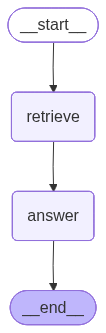

In [32]:
graph = StateGraph(GState)
# node 추가
graph.add_node('retrieve', retrieve_node)
graph.add_node('answer', answer_node)

# edge 추가. 시작점은 retrieve node
graph.set_entry_point('retrieve')
graph.add_edge('retrieve', 'answer')
graph.add_edge('answer', END)

# 중요!!!
# 멀티 턴 채팅을 위해 message를 저장한 memory
# checkpointer는 메모리 저장과 함께 그래프 내부의 상태도 저장
memory = MemorySaver()
app = graph.compile(checkpointer=memory)

from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

### 실행

In [33]:
def run(sid: str, text: str) -> str:
    res = app.invoke({'messages': [HumanMessage(content=text)]}, config={'configurable': {'thread_id': sid}})

    return res['messages'][-1].content

sid = 'user_001'
print(run(sid, '중도 해지 위약금 관련 조항들을 이용 약관을 근거로 요약해줘.'))
print('\n---------------------------------------------------------')
print(run(sid, '그 조항에서 고객 책임으로 명시된 부분만 다시 알려줘.'))
print('\n---------------------------------------------------------')
print(run(sid, '그 부분만 짧게 요약해줘'))

중도 해지 시 위약금 관련 내용은 다음과 같습니다.

- 장비임대의 경우: 해지 시까지 임대료가 청구되며, 계약기간 내에 중도 해지할 경우 장비임대료에 대한 위약금(할인반환금)을 납부해야 합니다. 위약금은 면제 또는 할인받은 금액에 이용 월 수를 곱한 금액으로 산정됩니다.

이 외에 중도 해지와 관련된 구체적인 위약금 조항은 제공된 컨텍스트에 포함되어 있지 않습니다.

[출처] 인터넷서비스_이용약관.pdf p.29; 인터넷서비스_이용약관.pdf p.28; 인터넷서비스_이용약관.pdf p.50

---------------------------------------------------------
중도 해지 위약금과 관련하여 고객 책임으로 명시된 부분은 다음과 같습니다.

- 고객이 계약기간 내에 중도 해지하는 경우, 장비임대료에 대한 할인반환금을 위약금으로 납부해야 합니다.

- 단, 군 입대, 사망 등 회사 책임 외에 고객 사유로 인한 해지 시 위약금은 면제되지 않습니다(군 입대 시 경품 제공 관련 위약금은 면제하지 않음).

이 외에 고객 책임 사유로 인한 위약금 관련 세부사항은 제공된 컨텍스트에 포함되어 있지 않습니다.

[출처] KT구내통신서비스_이용약관.pdf p.25; 인터넷서비스_이용약관.pdf p.10; 인터넷서비스_이용약관.pdf p.20

---------------------------------------------------------
고객이 계약 기간 중 중도 해지할 경우, 할인받은 장비임대료에 대한 위약금을 납부해야 합니다. 군 입대 등 특별한 사유 외에는 위약금 면제가 불가합니다.

[출처] 인터넷서비스_이용약관.pdf p.163; 인터넷서비스_이용약관.pdf p.28; KT구내통신서비스_이용약관.pdf p.25


In [ ]:
def run(sid: str, text: str) -> str:
    try:
        res = app.invoke({'messages': [HumanMessage(content=text)]}, config={'configurable': {'thread_id': sid}})

        return res['messages'][-1].content
    except Exception as e:  # 가끔 정책, 통신상의 문제로 오류가 발생할 수 있음
        print(f"Error occurred: {e}")
        return "문제가 발생해 답변드릴 수 없습니다."

sid = 'user_002'
print(run(sid, '인터넷 중도 해지 위약금 관련 조항을 이용 약관에서 근거로 요약해줘.'))
print('\n---------------------------------------------------------')
print(run(sid, '그 조항에서 고객 책임으로 명시된 부분만 다시 알려줘.'))
print('\n---------------------------------------------------------')
print(run(sid, '그 부분만 짧게 요약해줘'))

약관에 따르면 장비임대 상품의 경우, 계약 기간 내 중도 해지 시 장비 임대료를 반납해야 하며, 임대료 위약금은 '면제(또는 할인) 금액 × 이용 월 수'로 계산됩니다. 즉, 중도 해지 시 해당 장비에 대해 할인받은 금액만큼 위약금으로 청구될 수 있습니다.  
다만, 일반 요금제의 구체적인 중도 해지 위약금 조항에 대한 내용은 제공된 자료에 없습니다.

[출처] 인터넷서비스_이용약관_202509.pdf p.29; 인터넷서비스_이용약관_202509.pdf p.28; 인터넷서비스_이용약관_202509.pdf p.50

---------------------------------------------------------
제공된 자료에 따르면, 중도 해지 위약금과 관련하여 고객 책임으로 명시된 부분은 아래와 같습니다.

- 이용자가 중도 해지를 하는 경우, 장비 임대료 위약금이 발생하며, 이는 고객 책임입니다.
- 고객이 주소 변경 등 개인정보를 회사에 알리지 않아 청구서 부달 불가 등의 문제가 발생하는 경우 고객 책임입니다.
- 기타 이용자가 약관에 명시된 의무를 위반하여 불이익이 발생하는 경우 고객에게 책임이 있습니다.

구체적인 중도 해지 위약금 고객 책임 조항은 자료 내 명확히 구분되어 있지 않아 더 상세한 내용은 확인이 어렵습니다.

해당 질문에 대한 자료를 찾을 수 없습니다. 담당자에게 문의 바랍니다.

[출처] KT구내통신서비스_이용약관.pdf p.25; 인터넷서비스_이용약관_202509.pdf p.10; 인터넷서비스_이용약관_202509.pdf p.20

---------------------------------------------------------
중도 해지 시 발생하는 장비 임대료 위약금과 이용자의 주소 변경 미통지 등으로 인한 청구 문제는 모두 고객 책임입니다.

[출처] 인터넷서비스_이용약관_202509.pdf p.163; 인터넷서비스_이용약관_202509.pdf p.28; KT구내통신서비스_이용약관.pdf p.25


# 2. 메모리 관리


## 2.1) Window Memory

In [38]:
import os, glob
from typing import TypedDict, List, Annotated
from functools import partial

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages

from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage, SystemMessage
from langchain_core.output_parsers import StrOutputParser

메모리는 대화를 할수록 계속 추가되고 모든 대화 내용이 prompt에 들어가 토큰화돼 gpt에 전송됩니다.

이는 대화가 길어질 수록 두가지 문제를 일으킵니다.

1. 메모리와 토큰 낭비
1. 너무 많은 히스토리에서 정보를 제대로 찾지 못하거나 너무 과거 정보를 반영

이것을 위해 대화 히스토리를 제약해 줄 필요가 있습니다.

In [44]:
#가장 간단한 방법은 최근 k개의 메시지만 저장하는 것입니다.
def window_add(old: List[BaseMessage], new: List[BaseMessage], k: int) -> List[BaseMessage]:
    old = old or []
    new = new or []
    return (old + new)[-k:]

WINDOW = 4
window_partial = partial(window_add, k=WINDOW)

class GState(TypedDict):
    messages: Annotated[List[BaseMessage], window_partial]
    context: str
    refs: List[str]

In [46]:
def last_user_text(messages: List[BaseMessage]) -> str:
    """마지막 Human 발화 텍스트"""
    for m in reversed(messages):
        if isinstance(m, HumanMessage):
            return m.content
    return messages[-1].content if messages else '' # 메세지의 마지막 내용이 최신 Human 발화

rag_prompt = ChatPromptTemplate.from_messages([
    ('system',
     '너는 이용약관을 토대로 상담하는 통신사 상담사다. 아래 컨텍스트의 사실만 근거로 한국어로 답하라. '
     "가능한 답변하되 컨택스트에 근거가 너무 부족하면 억지로 지어내지 마.\n\n"
     '컨텍스트:\n{context}'),
    MessagesPlaceholder('messages'),
])

def retrieve_node(state: GState) -> GState:
    q = last_user_text(state['messages'])
    docs = retriever.invoke(q)

    context = '\n\n------\n\n'.join(d.page_content for d in docs)

    refs: List[str] = []
    seen = set()
    for d in docs:
        meta = d.metadata or {}
        src = meta.get('source') or meta.get('file_path') or meta.get('path')
        page = meta.get('page')
        if page is None:
            page = meta.get('page_number')
        disp_page = (page + 1) if isinstance(page, int) and page >= 0 else None
        if src:
            fname = os.path.basename(src)
            ref = f"{fname} p.{disp_page}" if disp_page is not None else f"{fname}"
            key = (fname, disp_page)
            if key not in seen:
                seen.add(key)
                refs.append(ref)

    return {'context': context, 'refs': refs}

llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,  
    azure_deployment=MODEL_NAME,          
    api_version="2024-12-01-preview",
    temperature=0.2,
)

def answer_node(state: GState) -> GState:
    out_msg = (rag_prompt | llm | StrOutputParser()).invoke({'messages': state['messages'], 'context': state.get('context','')})
    refs = state.get('refs', [])
    if refs:
        out = out_msg.rstrip() + '\n\n[출처] ' + '; '.join(refs[:3])
    return {'messages': [AIMessage(content=out)]}

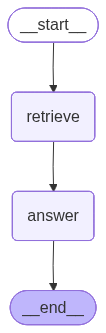

In [47]:
graph = StateGraph(GState)
# node 추가
graph.add_node('retrieve', retrieve_node)
graph.add_node('answer', answer_node)

# edge 추가. 시작점은 retrieve node
graph.set_entry_point('retrieve')
graph.add_edge('retrieve', 'answer')
graph.add_edge('answer', END)

memory = MemorySaver()
app_window_memory = graph.compile(checkpointer=memory)

from IPython.display import Image
Image(app_window_memory.get_graph().draw_mermaid_png())

In [48]:
def run(sid: str, text: str) -> str:
    try:
        res = app_window_memory.invoke({'messages': [HumanMessage(content=text)]}, config={'configurable': {'thread_id': sid}})
        return res['messages'][-1].content
    except Exception as e:
        print(f"Error occurred: {e}")
        return "문제가 발생해 답변드릴 수 없습니다."

sid = 'user_001'
print(run(sid, '인터넷 중도 해지 위약금 관련 조항을 이용 약관에서 근거로 요약해줘.'))
print('\n---------------------------------------------------------')
print(run(sid, '그 조항에서 고객 책임으로 명시된 부분만 다시 알려줘.'))
print('\n---------------------------------------------------------')
print(run(sid, '방금 대답을 아주 짧게 다시 요약해줘'))
print('\n---------------------------------------------------------')
print(run(sid, '가장 저렴한 요금제를 소개해줘'))
print('\n---------------------------------------------------------')
print(run(sid, '내가 했던 모든 질문이 뭐였지?'))

인터넷 중도 해지 시 위약금 관련 요약은 다음과 같습니다.

1. 장비임대료 위약금  
- 구내인터넷 Biz상품 이용 고객 대상 장비임대 시, 계약기간 내 중도 해지하면 장비임대료를 반납해야 합니다.  
- 위약금 산정은 면제 또는 할인받은 금액에 이용 월 수를 곱한 금액입니다.

2. 할인 반환금  
- 계약기간 또는 추가 계약기간 이내 해지하거나 계약기간 단축 시, 추가 할인된 요금을 반환해야 합니다.  
- 단, 특정 사유(제13조 제7항 각호)로 해지한 경우는 제외됩니다.  
- 반환 산정식은 할인전 월 이용료와 경과월수, 계약기간 할인율과 사용기간 할인율 차이를 반영합니다.  
- 올레 인터넷은 사용기간과 할인금액 차이를 곱하는 방식으로 산정합니다.

3. 프리미엄급 인터넷 모뎀 중도 반환 수수료  
- 중도 해지 또는 타상품 변경 시, 모뎀 중도 반환 수수료가 발생합니다.  
- 산정식은 (모뎀가격 – 기납부 금액) × 50%이며, 기납부 금액은 약정기간 요금을 기준으로 합니다.

4. 약정 할인 반환  
- 약정 할인액은 무약정 요금과 약정 별 요금 차이입니다.  
- 감면율은 (이용기간 – 180일) / (약정기간 – 180일) × 100%로 계산됩니다.  
- 2016년 4월 1일부터 2023년 9월 7일 사이 신규 접수된 일부 인터넷 상품은 약정기간별 총 할인금액과 할인반환금 할인율을 적용해 반환합니다.

요약하면, 인터넷 중도 해지 시에는 장비임대료, 할인반환금, 모뎀 반환 수수료 등이 위약금으로 청구될 수 있으며, 산정식과 적용 기준은 상품과 계약 조건에 따라 다릅니다.

[출처] KT구내통신서비스_이용약관.pdf p.20; 인터넷서비스_이용약관.pdf p.29; 인터넷서비스_이용약관.pdf p.89

---------------------------------------------------------
고객 책임으로 명시된 인터넷 중도 해지 위약금 관련 부분은 다음과 같습니다.

1. 할인 반환금  
- 계약기간 또는 추가 계약기간 이내

In [49]:
res = app_window_memory.invoke({'messages': [HumanMessage(content='가장 비싼 요금제는?')]}, config={'configurable': {'thread_id': sid}})

for m in res['messages']:
    print("--------------------------------")
    print(f'{m.type} : {m.content}')

--------------------------------
human : 내가 했던 모든 질문이 뭐였지?
--------------------------------
ai : 고객님께서 하신 질문은 다음과 같습니다.

1. "가장 저렴한 요금제를 소개해줘"
2. "가장 저렴한 요금제를 소개해줘" (중복 질문으로 보임)
3. "내가 했던 모든 질문이 뭐였지?"

이 외에는 별도의 질문이 없으셨습니다.

[출처] KT구내통신서비스_이용약관.pdf p.2; 기업형_메시지_이용약관.pdf p.11; KT구내통신서비스_이용약관.pdf p.25
--------------------------------
human : 가장 비싼 요금제는?
--------------------------------
ai : 컨텍스트에 따르면, Biz 서비스 요금표에서 50M 전용회선 속도의 월 요금이 647,900원(부가세 포함)으로 가장 높은 금액으로 나와 있습니다. 60M 요금은 일부만 나와 있어 정확한 금액은 확인되지 않으나, 50M 요금이 현재 제시된 금액 중 가장 비싼 요금입니다.

따라서, 가장 비싼 요금제는 Biz 서비스의 50M 전용회선 요금(월 647,900원)으로 보입니다.

[출처] 인터넷서비스_이용약관.pdf p.19

[출처] 인터넷서비스_이용약관.pdf p.57; KT구내통신서비스_이용약관.pdf p.16; KT구내통신서비스_이용약관.pdf p.19


In [50]:
res = app_window_memory.invoke({'messages': [HumanMessage(content='가장 비싼 요금제는?')]}, config={'configurable': {'thread_id': sid}})
print('1번째 질문')
res = app_window_memory.invoke({'messages': [HumanMessage(content='데이터 사용량이 많은 사람에게 추천해줄 요금제')]}, config={'configurable': {'thread_id': sid}})
print('2번째 질문')
res = app_window_memory.invoke({'messages': [HumanMessage(content='가장 빠른 통신 속도는?')]}, config={'configurable': {'thread_id': sid}})
print('3번째 질문')
res = app_window_memory.invoke({'messages': [HumanMessage(content='giga wifi의 종류는 어떤게 있어?')]}, config={'configurable': {'thread_id': sid}})
print('4번째 질문')
res = app_window_memory.invoke({'messages': [HumanMessage(content='나는 아주 사용량이 적어서 카톡만 되면 돼')]}, config={'configurable': {'thread_id': sid}})
print('5번째 질문')
res = app_window_memory.invoke({'messages': [HumanMessage(content='가장 최근에 나온 요금제가 뭐지?')]}, config={'configurable': {'thread_id': sid}})
print('6번째 질문')

for idx, m in enumerate(res['messages']):
    print(idx+1, '번째 메모리 ----------------------')
    print(f'{m.type} : {m.content}\n')

1번째 질문
2번째 질문
3번째 질문
4번째 질문
5번째 질문
6번째 질문
1 번째 메모리 ----------------------
human : 나는 아주 사용량이 적어서 카톡만 되면 돼

2 번째 메모리 ----------------------
ai : 카카오톡 등 간단한 메신저 사용만 원하신다면, 월 19,800원 요금제의 포스넷 서비스를 고려해 보실 수 있습니다. 이 서비스는 1 IP만 제공하며, 최대 2Mbps 속도로 신용카드 결제 및 보안장치 등 기계장치를 수용하는 서비스입니다. 다만, 신규 가입은 2018년 10월 29일부터 중단되었으니 참고해 주세요.

또한, KT WiFi 서비스는 중복 이용이 가능하므로, 필요에 따라 KT WiFi 서비스를 함께 이용하실 수도 있습니다.

더 자세한 상담이나 다른 요금제 문의가 필요하시면 언제든 말씀해 주세요.

[출처] 인터넷서비스_이용약관.pdf p.112; 인터넷서비스_이용약관.pdf p.60; 인터넷서비스_이용약관.pdf p.190

3 번째 메모리 ----------------------
human : 가장 최근에 나온 요금제가 뭐지?

4 번째 메모리 ----------------------
ai : 컨텍스트에 명확하게 가장 최근에 나온 요금제에 대한 정보는 포함되어 있지 않습니다. 다만, 부칙에 따르면 약관 시행일이 2008년 1월 21일, 2월 1일, 2월 14일 등으로 여러 차례 갱신된 기록이 있으나, 이 날짜들이 요금제 출시일과 직접 연결되지는 않습니다.

따라서, 가장 최근에 나온 요금제에 관한 구체적인 정보는 제공된 자료 내에 없습니다. 추가로 궁금하신 점이 있으면 알려주세요.

[출처] 인터넷서비스_이용약관.pdf p.57; 인터넷서비스_이용약관.pdf p.36; KT구내통신서비스_이용약관.pdf p.2



## 2.2) Trim Memory 

위의 윈도우 방식도 간단하고 쉽지만 매 턴의 길이가 차이 나는 경우 memory 공간만을 보면 들쑥날쑥할 수 있습니다.

trim을 사용하면 token수를 계산해서 비교적 일정한 길이의 history를 유지할 수 있습니다. 

token 수를 넘어가게 되면 가장 오래된 turn을 삭제합니다.

In [217]:
from langchain_core.messages import trim_messages

llm = AzureChatOpenAI(api_key=AZURE_OPENAI_API_KEY,
                    azure_endpoint=END_POINT,  
                    azure_deployment=MODEL_NAME,
                    model='gpt-5-mini',          
                    api_version="2024-12-01-preview",
                )

def add_n_trim(old: List[BaseMessage], new: List[BaseMessage]) -> List[BaseMessage]:
    old = old or []
    new = new or []
    messages = old + new
    trimed_messages = trim_messages(messages, 
                                    max_tokens=500,
                                    strategy='last',
                                    token_counter=llm,  # 토큰의 길이를 측정하는 모델 지정하기
                                    )
    
    return trimed_messages

class GState(TypedDict):
    messages: Annotated[List[BaseMessage], add_n_trim]
    context: str
    refs: List[str]

In [218]:
def last_user_text(messages: List[BaseMessage]) -> str:
    """마지막 Human 발화 텍스트"""
    for m in reversed(messages):
        if isinstance(m, HumanMessage):
            return m.content
    return messages[-1].content if messages else '' # 메세지의 마지막 내용이 최신 Human 발화

rag_prompt = ChatPromptTemplate.from_messages([
    ('system',
     '너는 이용약관을 토대로 상담하는 통신사 상담사다. 아래 컨텍스트의 사실만 근거로 한국어로 답하라. '
     "가능한 답변하되 컨택스트에 근거가 너무 부족하면 억지로 지어내지 마.\n\n"
     '컨텍스트:\n{context}'),
    MessagesPlaceholder('messages'),
])

def retrieve_node(state: GState) -> GState:
    q = last_user_text(state['messages'])
    docs = retriever.invoke(q)

    context = '\n\n------\n\n'.join(d.page_content for d in docs)

    refs: List[str] = []
    seen = set()
    for d in docs:
        meta = d.metadata or {}
        src = meta.get('source') or meta.get('file_path') or meta.get('path')
        page = meta.get('page')
        if page is None:
            page = meta.get('page_number')
        disp_page = (page + 1) if isinstance(page, int) and page >= 0 else None
        if src:
            fname = os.path.basename(src)
            ref = f"{fname} p.{disp_page}" if disp_page is not None else f"{fname}"
            key = (fname, disp_page)
            if key not in seen:
                seen.add(key)
                refs.append(ref)

    return {'context': context, 'refs': refs}

llm = AzureChatOpenAI(api_key=AZURE_OPENAI_API_KEY,
                    azure_endpoint=END_POINT,  
                    azure_deployment=MODEL_NAME,
                    model='gpt-5-mini',          
                    api_version="2024-12-01-preview",
                )

def answer_node(state: GState) -> GState:
    out_msg = (rag_prompt | llm | StrOutputParser()).invoke({'messages': state['messages'], 'context': state.get('context','')})
    refs = state.get('refs', [])
    if refs:
        out = out_msg.rstrip() + '\n\n[출처] ' + '; '.join(refs[:3])
    return {'messages': [AIMessage(content=out)]}

graph = StateGraph(GState)
# node 추가
graph.add_node('retrieve', retrieve_node)
graph.add_node('answer', answer_node)

# edge 추가. 시작점은 retrieve node
graph.set_entry_point('retrieve')
graph.add_edge('retrieve', 'answer')
graph.add_edge('answer', END)

memory = MemorySaver()
app_trim_memory = graph.compile(checkpointer=memory)

In [219]:
res = app_trim_memory.invoke({'messages': [HumanMessage(content='가장 비싼 요금제는?')]}, config={'configurable': {'thread_id': sid}})
print('1번째 질문')
res = app_trim_memory.invoke({'messages': [HumanMessage(content='데이터 사용량이 많은 사람에게 추천해줄 요금제')]}, config={'configurable': {'thread_id': sid}})
print('2번째 질문')
res = app_trim_memory.invoke({'messages': [HumanMessage(content='가장 빠른 통신 속도는?')]}, config={'configurable': {'thread_id': sid}})
print('3번째 질문')
res = app_trim_memory.invoke({'messages': [HumanMessage(content='giga wifi의 종류는 어떤게 있어?')]}, config={'configurable': {'thread_id': sid}})
print('4번째 질문')
res = app_trim_memory.invoke({'messages': [HumanMessage(content='나는 아주 사용량이 적어서 카톡만 되면 돼')]}, config={'configurable': {'thread_id': sid}})
print('5번째 질문')
res = app_trim_memory.invoke({'messages': [HumanMessage(content='가장 최근에 나온 요금제가 뭐지?')]}, config={'configurable': {'thread_id': sid}})
print('6번째 질문')

all_text = ''
for idx, m in enumerate(res['messages']):
    print(idx+1, '번째 메모리 ----------------------')
    print(f'{m.type} : {m.content}\n')
    all_text += m.content

1번째 질문
2번째 질문
3번째 질문
4번째 질문
5번째 질문
6번째 질문
1 번째 메모리 ----------------------
human : 나는 아주 사용량이 적어서 카톡만 되면 돼

2 번째 메모리 ----------------------
ai : 카카오톡만 사용하실 정도로 사용량이 적다면, 초고속인터넷을 꼭 고속으로 선택하지 않아도 되실 것 같습니다. 예를 들어, 포스넷 서비스는 월 19,800원에 1 IP만 제공하며, 최대 2Mbps 속도로 신용카드 결제 등 기계장치를 수용하는 서비스입니다. 속도는 낮지만 가벼운 인터넷 사용에는 충분합니다.

또한 이용량이 매우 적다면, 일수 단위로 이용한 만큼 요금을 내는 KT biz kornet 서비스도 고려해볼 수 있습니다. 이 서비스는 1개월 이내 이용고객이 이용한 일수에 따라 요금을 계산합니다.

필요에 맞게 선택하시면 좋겠습니다.

[출처] 인터넷서비스_이용약관_202509.pdf p.112; 인터넷서비스_이용약관_202509.pdf p.60; 인터넷서비스_이용약관_202509.pdf p.190

3 번째 메모리 ----------------------
human : 가장 최근에 나온 요금제가 뭐지?

4 번째 메모리 ----------------------
ai : 컨텍스트에 따르면, 가장 최근에 시행된 약관은 2008년 2월 14일부터 시행된 약관입니다. 다만, 구체적인 요금제 명칭이나 신규 요금제에 대한 직접적인 언급은 없으며, 결합할인 중 프리요금제는 2008년 4월 1일부터 시행된다는 내용이 있습니다.

따라서, 가장 최근에 나온 요금제는 '프리요금제'로 보이며, 이 요금제는 2008년 4월 1일부터 시행되었습니다.

[출처] 부칙 시행일 관련 내용(2008년 1월 21일, 2월 1일, 2월 14일 시행과 4월 1일부터 결합할인 프리요금제 시행)

[출처] 인터넷서비스_이용약관_202509.pdf p.57; 인터넷서비스_이용약관_202509.pdf p.36; KT구내통신서비스_이용약관.pdf p

In [220]:
message_token = llm.invoke(all_text).response_metadata['token_usage']['prompt_tokens']
print(f'메시지 토큰 수: {message_token}')

메시지 토큰 수: 470


## 2.3) Summarizing (combined) Memory

앞에서 메모리에 윈도우를 포함해서 히스토리를 최신으로 유지하는 것을 구현했습니다.

그러나 앞의 방법은 윈도우를 벗어나는 순간 과거 정보가 모두 소실되어 버립니다.

장기 메모리에도 중요한 내용이 있을 수 있기 때문에 이것도 같이 어느정보 보존해 줄 필요가 있습니다.

이를 위해 장기 기억에서 중요한 부분만 따로 관리해줄 요약 메모리를 같이 도입할 수 있습니다.

In [88]:
def window_add(old: List[BaseMessage], new: List[BaseMessage], k: int) -> List[BaseMessage]:
    old = old or []
    new = new or []
    return (old + new)[-k:]

WINDOW = 6
WINDOW_REDUCER = partial(window_add, k=WINDOW)

class GState(TypedDict):
    messages: Annotated[List[BaseMessage], WINDOW_REDUCER]  # ← 최근 WINDOW턴 유지
    context: str                                           # ← RAG 컨텍스트
    refs: List[str]                                        # ← 파일/페이지 출처
    summ_memory: str                                      # ← 장기 메모리 요약

In [89]:
def last_user_text(messages: List[BaseMessage]) -> str:
    """마지막 Human 발화 텍스트"""
    for m in reversed(messages):
        if isinstance(m, HumanMessage):
            return m.content
    return messages[-1].content if messages else ''

def retrieve_node(state: GState) -> GState:
    q = last_user_text(state['messages'])
    docs = retriever.invoke(q)  

    context = '\n\n---\n\n'.join(d.page_content for d in docs)

    refs: List[str] = []
    seen = set()
    for d in docs:
        meta = d.metadata or {}
        src = meta.get('source') or meta.get('file_path') or meta.get('path')
        page = meta.get('page')
        if page is None:
            page = meta.get('page_number')
        disp_page = (page + 1) if isinstance(page, int) and page >= 0 else None
        if src:
            fname = os.path.basename(src)
            ref = f"{fname} p.{disp_page}" if disp_page is not None else f"{fname}"
            key = (fname, disp_page)
            if key not in seen:
                seen.add(key)
                refs.append(ref)

    return {'context': context, 'refs': refs}

rag_prompt = ChatPromptTemplate.from_messages([
    ('system',
     '아래 컨텍스트의 사실만 근거로 한국어로 답하라. '
     '유저나 과거 정보에 대한 질문이라면 간단하게 답하라'
     "사실 관계가 중요한 질문을 했을 때 근거가 부족하면 억지로 지어내지 마P라.\n\n"
     "[장기요약]:\n{summ}"
     '[컨텍스트]:\n{context}'),
    MessagesPlaceholder('messages'),
])

def answer_node(state: GState) -> GState:
    out_msg = (rag_prompt | llm | StrOutputParser()).invoke(
        {'messages': state['messages']
        , 'context': state.get('context','')
        , 'summ': state.get('summ_memory','')})  # ✅ 수정: summ_memory 사용
    refs = state.get('refs', [])
    if refs:
        out = out_msg + '\n\n[출처] ' + '; '.join(refs[:3])
    return {'messages': [AIMessage(content=out)]}


def history_summarize_node(state: GState) -> GState:

    # 요약 입력: summ + 최근 메시지들의 윈도우

    # ✅ 수정: 2개 이상이면 요약 (첫 질문부터 요약)
    if len(state['messages']) >= 2:
        prev_summ = state.get('summ_memory', '과거 정보 없음')
        # ✅ 전체 메시지 요약 (window 내 모든 정보 포함)
        tail_dump = "\n".join(m.content for m in state['messages'])

        system_hint = (
            "당신은 '챗봇 장기 기억'을 만들기 위한 히스토리 요약기다. "
            "목표는 사용자의 개인 정보(이름/선호/약속/사실), 결정사항 등 지속적으로 대화에 사용될 유용한 정보만 남기는 것이다. "
            "\n\n**핵심 규칙:**\n"
            "1. 기존 요약에 있던 확실한 사실(특히 사용자 이름)은 절대 삭제하지 마라.\n"
            "2. AI가 '정보가 없다'/'제공받지 못함'이라고 답한 내용은 무시하라. (임시 답변일 뿐)\n"
            "3. 사용자가 직접 말한 정보만 신뢰하라.\n"
            "4. 일회성 잡담은 제거하라.\n"
            "5. 핵심만 10문장 이내 불릿 리스트로 작성해라."
        )

        prompt = ChatPromptTemplate.from_messages([
                    SystemMessage(content=system_hint),
                    HumanMessage(content=(
                        f"[기존 요약]\n{prev_summ}\n\n"
                        f"[최근 대화]\n{tail_dump}\n\n"
                        "위 정보를 종합하여 장기 기억에 적합한 핵심 요약을 새로 작성해라."
                        ))
                ])
        new_sum = (prompt | llm | StrOutputParser()).invoke({})

        return {"summ_memory": new_sum}
    else:
        return {}

In [90]:
graph = StateGraph(GState)
graph.add_node('retrieve', retrieve_node)
graph.add_node('answer', answer_node)
graph.add_node('history_summarize', history_summarize_node)   

graph.set_entry_point('retrieve')
graph.add_edge('retrieve', 'answer')
graph.add_edge('answer', 'history_summarize')               
graph.add_edge('history_summarize', END)

memory = MemorySaver()
app_summarize_memory = graph.compile(checkpointer=memory)

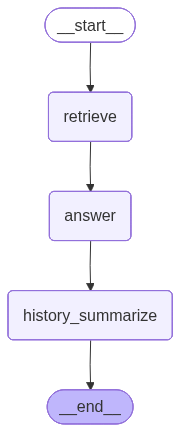

In [91]:
from IPython.display import Image
Image(app_summarize_memory.get_graph().draw_mermaid_png())

In [92]:
# 히스토리 초기화: 새로운 MemorySaver로 앱 재컴파일
memory = MemorySaver()
app_summarize_memory = graph.compile(checkpointer=memory)
print("✅ 히스토리가 초기화되었습니다.\n")

qs = ['안녕 내 이름은 김진태야',
       '가장 비싼 요금제는?',
       '데이터 사용량이 많은 사람에게 추천해줄 요금제',
       '오늘 날씨가 좋아서 참 기분이 좋아',
        '통신 속도가 가장 빠른 인터넷 요금제는?',
        ]

for i, q in enumerate(qs):
    res = app_summarize_memory.invoke({'messages': [HumanMessage(content=q)]}, config={'configurable': {'thread_id': sid}})
result = app_summarize_memory.invoke({'messages': [HumanMessage(content='내 이름 누구야?')]}, config={'configurable': {'thread_id': sid}})
print(result.get('messages')[-1].content)

print('\n\n\n')
for k in result.keys():
    if k != 'context':
        print(f'[{k}]=========================================')
        if isinstance(result[k], list):
            for i, r in enumerate(result[k]):
                print(f'\t{i+1}. {r}')
        else:
            print(result[k])

✅ 히스토리가 초기화되었습니다.

사용자 이름은 김진태입니다.

[출처] 기업형_메시지_이용약관.pdf p.17; 인터넷서비스_이용약관.pdf p.227; 기업형_메시지_이용약관.pdf p.15




[messages]=========================================
	1. content='오늘 날씨가 좋아서 참 기분이 좋아' additional_kwargs={} response_metadata={}
	2. content='기분이 좋으시다니 다행입니다! 도움이 필요하시면 언제든 말씀해 주세요.\n\n[출처] KT구내통신서비스_이용약관.pdf p.16; 기업형_메시지_이용약관.pdf p.16; 기업형_메시지_이용약관.pdf p.15' additional_kwargs={} response_metadata={}
	3. content='통신 속도가 가장 빠른 인터넷 요금제는?' additional_kwargs={} response_metadata={}
	4. content='제공된 정보에 따르면, 가장 빠른 인터넷 속도를 제공하는 요금제는 1.25Gbps 속도의 요금제입니다. 다만, 구체적인 요금이나 상품명은 명확히 나와 있지 않습니다. Biz 서비스에서는 60M 속도 요금제가 가장 높은 속도 중 하나로 확인됩니다.\n\n[출처] 인터넷서비스_이용약관.pdf p.57; KT구내통신서비스_이용약관.pdf p.16\n\n[출처] 인터넷서비스_이용약관.pdf p.185; 인터넷서비스_이용약관.pdf p.59; 인터넷서비스_이용약관.pdf p.221' additional_kwargs={} response_metadata={}
	5. content='내 이름 누구야?' additional_kwargs={} response_metadata={}
	6. content='사용자 이름은 김진태입니다.\n\n[출처] 기업형_메시지_이용약관.pdf p.17; 인터넷서비스_이용약관.pdf p.227; 기업형_메시지_이용약관.pdf p.15' additional_